# Model Improvement — Feature Engineering + Model Selection

- [`01_eda.ipynb`](./01_eda.ipynb) — five findings that drive this notebook: (a) a bimodal weekday commute curve at ~8 AM and ~5 PM, (b) a strong `hour x is_weekend` interaction (weekdays bimodal, weekends unimodal), (c) clear year-over-year growth (every 2012 month sits well above its 2011 counterpart), (d) a right-skewed target (median 142, max 977, min 1), and (e) weather signals that are real but second-order to temporal ones.
- [`02_baseline_linear_regression.ipynb`](./02_baseline_linear_regression.ipynb) — `LinearRegression` on the minimal feature set reached **test RMSE 200.34, MAE 135.25, R² 0.174**. Residuals fanned out at commute hours (the bimodal curve is unrepresentable in an additive linear model) and the train/test R² gap (0.354 → 0.174) reflected the 2012 ramp that the baseline deliberately did not see (`year` was dropped on purpose).

**Plan for this notebook**

1. **Feature engineering** targeted at the diagnosed weaknesses: cyclic `hour` (so the model can represent a circular time-of-day), an `is_peak_hour` interaction flag (the `hour x is_weekend` shape), and lag features (`lag_1h`, `lag_168h`) that absorb both short-term autocorrelation and weekly seasonality.
2. **A sequence of experiments** on the *same* chronological train/test split so the comparison is honest:
   - **Ridge** — how far can we get by fixing only the features?
   - **Ridge + `log1p(target)`** — does correcting for the right-skewed target help a linear model?
   - **Random Forest** — does a non-linear model capture the bimodality and the interaction natively?
   - **XGBoost** — three configurations (default / shallow / deep) to test whether tuning is needed; the brief mentions XGBoost explicitly.
   - **XGBoost + `log1p(target)`** — same three configurations through a log-target transformer.
3. **Pick a winner** from a single comparison table and verify it with the same three diagnostic plots used in the baseline notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 0

## 1. Load the prepared dataset

Same preprocessed dataset used by `01_eda.ipynb` and `02_baseline_linear_regression.ipynb`. We sort by `datetime` up-front so the lag features (next section) shift in the correct direction and the chronological 80/20 split is deterministic.

In [2]:
df = (
    pd.read_csv(
        "../data/output-local/final_dataset.csv",
        parse_dates=["datetime"],
    )
    .sort_values("datetime")
    .reset_index(drop=True)
)

## 2. Feature engineering

Three groups of additions, each tied to a specific weakness from the EDA / baseline:

**Cyclic encoding of `hour`** (`hour_sin`, `hour_cos`).
The baseline used raw `hour` as a single linear variable, forcing a monotone effect across the day. In reality hour 23 is *adjacent* to hour 0 on the clock, and demand peaks twice. Sine/cosine pair encodes the 24-hour cycle so the model gets a smooth circular representation of time-of-day without hand-coding peak times.

**Peak-hour interaction flag** (`is_peak_hour`).
The bimodal weekday curve and unimodal weekend curve are the dominant unmodelled effect from the baseline. `is_peak_hour=1` on weekdays during 7-9 / 17-19 and on weekends during 12-16; `0` otherwise. This explicitly encodes the `hour x is_weekend` interaction the EDA flagged, so a linear model can split its effect by regime and a tree model gets a ready-made splitting variable.

**Lag features** (`lag_1h`, `lag_24h`, `lag_168h`).
Hourly rental counts are strongly autocorrelated. `lag_1h` (previous hour) captures short-term trajectory; `lag_168h` (same hour last week) absorbs day-of-week structure, weekly seasonality, *and* slow-moving year-over-year growth in one feature. This last point is important: with `lag_168h` in the feature set, we no longer need an explicit `year` column (which is brittle — it cannot extrapolate beyond 2012). `lag_24h` is included here and evaluated in section 3.

**Light cleaning**: booleans cast to `int` (for the linear models), and `light_rain` / `heavy_rain` are collapsed into a single `rain` category — the EDA showed `heavy_rain` had only 3 rows, and its one-hot coefficient would otherwise be pure noise.

Lag operations introduce NaNs in the first 168 rows; we drop them so every experiment trains on a complete feature matrix.

In [3]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclic hour encoding and a weekday/weekend peak-hour flag."""
    out = df.copy()

    out["is_weekend"] = out["is_weekend"].astype(int)
    out["is_holiday"] = out["is_holiday"].astype(int)

    out["conditions"] = out["conditions"].replace(
        {"light_rain": "rain", "heavy_rain": "rain"}
    )

    # `month` and `year` come from preprocessing — no need to derive them.
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)

    out["is_peak_hour"] = 0
    out.loc[
        (
            (out["hour"].between(7, 9) | out["hour"].between(17, 19))
            & (out["is_weekend"] == 0)
        )
        | ((out["hour"].between(12, 16)) & (out["is_weekend"] == 1)),
        "is_peak_hour",
    ] = 1

    return out


def add_lag_features(
    df: pd.DataFrame, target_col: str = "total_count"
) -> pd.DataFrame:
    """Append lag_1h, lag_24h, and lag_168h shifts of the target column."""
    out = df.copy()
    s = out[target_col]

    out["lag_1h"] = s.shift(1)
    out["lag_24h"] = s.shift(24)
    out["lag_168h"] = s.shift(168)

    return out


df_eng = engineer(df)
df_eng = add_lag_features(df_eng).dropna().reset_index(drop=True)

df_eng.head()

,datetime,total_count,hour,day_of_month,month,year,week,day_of_week,is_weekend,conditions,...,perceived_temperature_c,humidity,windspeed_kmh,is_holiday,hour_sin,hour_cos,is_peak_hour,lag_1h,lag_24h,lag_168h
0,2011-01-08 07:00:00,9,7,8,1,2011,1,5,1,clouds,...,-4.0,74.0,7.0,0,0.965926,-0.258819,0,2.0,84.0,16.0
1,2011-01-08 08:00:00,15,8,8,1,2011,1,5,1,rain,...,-4.0,93.0,7.0,0,0.866025,-0.500000,0,9.0,210.0,40.0
2,2011-01-08 09:00:00,20,9,8,1,2011,1,5,1,rain,...,-4.0,93.0,7.0,0,0.707107,-0.707107,0,15.0,134.0,32.0
3,2011-01-08 10:00:00,61,10,8,1,2011,1,5,1,clouds,...,-3.0,80.0,11.0,0,0.500000,-0.866025,0,20.0,63.0,13.0
4,2011-01-08 11:00:00,62,11,8,1,2011,1,5,1,clouds,...,-4.0,69.0,26.0,0,0.258819,-0.965926,0,61.0,67.0,1.0


## 3. Chronological split and feature selection

**Split.** Same chronological 80/20 split style as the baseline — first 80% of hours train, last 20% test. A random shuffle would leak future hours into training given the YoY growth and seasonality in the data.

**Feature selection rationale.** We drop columns that are either (a) absorbed by other features or (b) flagged by the EDA as unhelpful:

- `datetime`, `day_of_month`, `week` — calendar artefacts already shown to have no behavioural signal in the EDA (Section 5).
- `month`, `year` — seasonality and trend are now carried by `lag_168h` (same hour last week). Keeping `month`/`year` alongside it would just split the same signal across multiple coefficients.
- `temperature_c`, `perceived_temperature_c`, `humidity`, `windspeed_kmh` — weather has a real but second-order effect on demand. Once the model knows what happened an hour ago (`lag_1h`) and what happened on the same hour last week (`lag_168h`), most of the weather effect is already baked into those values (people who actually rode reflect the weather that was).
- `lag_24h` — high pairwise correlation with both `lag_1h` and `lag_168h`. We keep the two complementary lags (very short term + weekly) and drop the daily one to avoid multicollinearity in the linear models.

**Kept features (10 total).** Original behavioural signals (`hour`, `day_of_week`, `is_weekend`, `is_holiday`), engineered time features (`hour_sin`, `hour_cos`, `is_peak_hour`), two lags (`lag_1h`, `lag_168h`), and one-hot-encoded `conditions`.

In [4]:
DROPPED = [
    "datetime",
    "day_of_month",
    "month",
    "year",
    "week",
    "temperature_c",
    "perceived_temperature_c",
    "humidity",
    "windspeed_kmh",
    "lag_24h",
]

TARGET = "total_count"

FEATURES_NUM = [
    "hour",
    "day_of_week",
    "is_weekend",
    "is_holiday",  # original features
    "hour_sin",
    "hour_cos",
    "is_peak_hour",  # cyclic features and interaction feature
    "lag_1h",
    "lag_168h",  # lag features
]
FEATURES_CAT = ["conditions"]
FEATURES_ALL = FEATURES_NUM + FEATURES_CAT

split_idx = int(len(df_eng) * 0.8)
df_train = df_eng.iloc[:split_idx].reset_index(drop=True)
df_test = df_eng.iloc[split_idx:].reset_index(drop=True)

X_train = df_train[FEATURES_ALL]
X_test = df_test[FEATURES_ALL]
y_train = df_train[TARGET]
y_test = df_test[TARGET]

train_start = df_train["datetime"].iloc[0]
train_end = df_train["datetime"].iloc[-1]
test_start = df_test["datetime"].iloc[0]
test_end = df_test["datetime"].iloc[-1]

print(f"Train: {len(df_train):>6} rows  | {train_start}  →  {train_end}")
print(f"Test:  {len(df_test):>6} rows  | {test_start}  →  {test_end}")
print(
    f"Feature count: {len(FEATURES_ALL)}  "
    f"({len(FEATURES_NUM)} numeric, {len(FEATURES_CAT)} categorical)"
)
X_train.head()

Train:  13768 rows  | 2011-01-08 07:00:00  →  2012-08-08 20:00:00
Test:    3443 rows  | 2012-08-08 21:00:00  →  2012-12-31 23:00:00
Feature count: 10  (9 numeric, 1 categorical)


,hour,day_of_week,is_weekend,is_holiday,hour_sin,hour_cos,is_peak_hour,lag_1h,lag_168h,conditions
0,7,5,1,0,0.965926,-0.258819,0,2.0,16.0,clouds
1,8,5,1,0,0.866025,-0.500000,0,9.0,40.0,rain
2,9,5,1,0,0.707107,-0.707107,0,15.0,32.0,rain
3,10,5,1,0,0.500000,-0.866025,0,20.0,13.0,clouds
4,11,5,1,0,0.258819,-0.965926,0,61.0,1.0,clouds


## 4. Shared evaluation harness

Every experiment is fit and scored through the same `evaluate()` function and appended to a single `results` dict so the final comparison is apples-to-apples. Metrics:

- **RMSE** — same units as the target (rentals/hour); penalises large errors more.
- **MAE** — same units; robust to outliers, easy to interpret.
- **R²** — unitless; share of variance explained relative to predicting the mean.

We seed the table with the baseline numbers from [`02_baseline_linear_regression.ipynb`](./02_baseline_linear_regression.ipynb) as row `00`. The baseline is not re-fit here; the numbers are copied so they appear in the same comparison table as everything else.

In [5]:
results: dict[str, dict] = {}


def evaluate(
    name: str, model, X_tr, y_tr, X_te, y_te, **fit_kwargs
) -> np.ndarray:
    """Fit model, store train/test metrics, and return test predictions."""
    model.fit(X_tr, y_tr, **fit_kwargs)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    metrics = {
        "rmse_train": np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        "rmse_test": np.sqrt(mean_squared_error(y_te, y_pred_te)),
        "mae_train": mean_absolute_error(y_tr, y_pred_tr),
        "mae_test": mean_absolute_error(y_te, y_pred_te),
        "r2_train": r2_score(y_tr, y_pred_tr),
        "r2_test": r2_score(y_te, y_pred_te),
    }
    results[name] = metrics
    rmse_part = (
        f"RMSE(tr/te)={metrics['rmse_train']:6.2f}/{metrics['rmse_test']:6.2f}"
    )
    mae_part = (
        f"MAE(tr/te)={metrics['mae_train']:6.2f}/{metrics['mae_test']:6.2f}"
    )
    r2_part = f"R²(tr/te)={metrics['r2_train']:.3f}/{metrics['r2_test']:.3f}"
    print(f"{name:<40} | {rmse_part} | {mae_part} | {r2_part}")
    return y_pred_te


# Baseline from notebook 02 (model is not re-fit here).
results["00 Baseline (LinearRegression)"] = {
    "rmse_train": 134.23,
    "rmse_test": 200.34,
    "mae_train": 98.66,
    "mae_test": 135.25,
    "r2_train": 0.354,
    "r2_test": 0.174,
}
print(
    "00 Baseline (LinearRegression)   | "
    "RMSE(tr/te)=134.23/200.34 | "
    "MAE(tr/te)=98.66/135.25 | "
    "R²(tr/te)=0.354/0.174"
)

00 Baseline (LinearRegression)   | RMSE(tr/te)=134.23/200.34 | MAE(tr/te)=98.66/135.25 | R²(tr/te)=0.354/0.174


## 5. Experiment 1 — Ridge

First question: how far can feature engineering alone close the gap, *without* moving to a non-linear model?

We use `Ridge` rather than `LinearRegression` because the engineered set deliberately includes correlated time-of-day features (`hour`, `hour_sin`, `hour_cos`, `is_peak_hour` all encode time differently). L2 regularisation keeps the coefficients stable under collinearity. `StandardScaler` is added so the regularisation penalty applies uniformly across raw feature magnitudes (`lag_1h` ranges 0-977, `hour_sin` ranges -1-1).

In [6]:
preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_NUM),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            FEATURES_CAT,
        ),
    ]
)

ridge = Pipeline(
    [
        ("preprocess", preprocess_linear),
        ("regressor", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]
)
_ = evaluate("01 Ridge", ridge, X_train, y_train, X_test, y_test)

01 Ridge                                 | RMSE(tr/te)= 68.86/ 94.54 | MAE(tr/te)= 45.48/ 62.40 | R²(tr/te)=0.832/0.815


## 6. Experiment 2 — Ridge with `log1p`-transformed target

The EDA showed the target is right-skewed (median 142, max 977). A linear model on the raw target spends much of its loss budget on the long tail; fitting on `log1p(total_count)` rebalances large vs typical hours and (as a side effect) makes negative predictions impossible after `expm1` inversion.

`TransformedTargetRegressor` applies the transform during fit and inverts it during predict, so reported metrics stay in the original `total_count` scale and remain directly comparable to every other row in the comparison table.

In [7]:
ridge_log = TransformedTargetRegressor(
    regressor=Pipeline(
        [
            ("preprocess", preprocess_linear),
            ("regressor", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)
_ = evaluate(
    "02 Ridge + log1p(target)", ridge_log, X_train, y_train, X_test, y_test
)

02 Ridge + log1p(target)                 | RMSE(tr/te)=175.76/384.37 | MAE(tr/te)= 79.57/160.71 | R²(tr/te)=-0.096/-2.057


## 7. Experiment 3 — Random Forest

Tree ensembles split on raw feature values and can express the things a plain linear model cannot:
- The bimodal weekday curve, through separate leaves for commute hours vs the rest.
- The `hour x is_weekend` interaction, through sequential splits on the two columns.
- Non-linear lag effects (e.g. saturation at very high `lag_1h` values).

We feed the *same* feature matrix as the linear experiments so this comparison isolates the **model class** — not the feature set. The preprocessor is minimal: one-hot encode `conditions`, pass everything else through (trees don't need scaling).

In [8]:
preprocess_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            FEATURES_CAT,
        ),
    ],
    remainder="passthrough",
)

rf = Pipeline(
    [
        ("preprocess", preprocess_tree),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
_ = evaluate("03 RandomForest", rf, X_train, y_train, X_test, y_test)

03 RandomForest                          | RMSE(tr/te)= 18.78/ 49.79 | MAE(tr/te)= 11.27/ 30.29 | R²(tr/te)=0.987/0.949


## 8. Experiment 4 — XGBoost (three configurations)

Gradient-boosted trees are the standard high-performer on tabular regression. Compared to Random Forest, boosting fits residuals iteratively and usually beats bagging on bias for the same compute. The brief explicitly mentions XGBoost.

We sweep three configurations along the depth / regularisation axis to test whether the defaults sit in a sensible operating point or need adjustment:

- **default** — `n_estimators=600, max_depth=6, learning_rate=0.05`. Sensible starting point.
- **shallow** — smaller trees (`max_depth=4`), fewer rounds, added L1/L2 regularisation. Sanity check that we are not over-fitting at depth 6.
- **deep** — bigger trees (`max_depth=8`), more rounds (`1200`), lower learning rate (`0.03`). Does going deeper help?

All three share `subsample=0.9, colsample_bytree=0.9, tree_method="hist"` for stochastic regularisation and fast training.

In [9]:
xgb_para_configs = {
    "default": xgb.XGBRegressor(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "shallow": xgb.XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=0.5,
        reg_lambda=1.0,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "deep": xgb.XGBRegressor(
        n_estimators=1200,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

for name, configs in xgb_para_configs.items():
    xgb_pipeline = Pipeline(
        [
            ("preprocess", preprocess_tree),
            ("regressor", configs),
        ]
    )
    _ = evaluate(
        f"04 XGBoost ({name})", xgb_pipeline, X_train, y_train, X_test, y_test
    )

04 XGBoost (default)                     | RMSE(tr/te)= 21.39/ 46.27 | MAE(tr/te)= 14.69/ 29.19 | R²(tr/te)=0.984/0.956
04 XGBoost (shallow)                     | RMSE(tr/te)= 30.96/ 47.13 | MAE(tr/te)= 20.40/ 30.58 | R²(tr/te)=0.966/0.954
04 XGBoost (deep)                        | RMSE(tr/te)= 12.70/ 47.28 | MAE(tr/te)=  8.84/ 29.73 | R²(tr/te)=0.994/0.954


## 9. Experiment 5 — XGBoost with `log1p(target)`

Run the same three configurations wrapped in `TransformedTargetRegressor`. Trees do not strictly need the target transform (they are scale-invariant on the input side, and the loss is computed in whatever space we train), but log-space training spreads error budget more evenly across the long tail of the target — which often produces a small but real lift on right-skewed regression problems. We test it here to confirm or refute that intuition for this dataset.

In [10]:
for name, configs in xgb_para_configs.items():
    xgb_log1p = TransformedTargetRegressor(
        regressor=Pipeline(
            [
                ("preprocess", preprocess_tree),
                ("regressor", configs),
            ]
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    )
    _ = evaluate(
        f"05 XGBoost + log1p(target) ({name})",
        xgb_log1p,
        X_train,
        y_train,
        X_test,
        y_test,
    )

05 XGBoost + log1p(target) (default)     | RMSE(tr/te)= 26.76/ 45.47 | MAE(tr/te)= 16.91/ 28.63 | R²(tr/te)=0.975/0.957
05 XGBoost + log1p(target) (shallow)     | RMSE(tr/te)= 33.40/ 48.03 | MAE(tr/te)= 20.89/ 30.17 | R²(tr/te)=0.960/0.952
05 XGBoost + log1p(target) (deep)        | RMSE(tr/te)= 19.72/ 45.67 | MAE(tr/te)= 11.98/ 28.68 | R²(tr/te)=0.986/0.957


## 10. Final comparison

All experiments scored on the same test set, sorted by test RMSE (lower is better). This single table is the basis for picking the winner in the next section.

In [11]:
summary = pd.DataFrame(results).T
summary = summary[
    ["rmse_train", "rmse_test", "mae_train", "mae_test", "r2_train", "r2_test"]
]
summary = summary.sort_values("rmse_test")
summary.round(3)

,rmse_train,rmse_test,mae_train,mae_test,r2_train,r2_test
05 XGBoost + log1p(target) (default),26.761,45.472,16.915,28.632,0.975,0.957
05 XGBoost + log1p(target) (deep),19.724,45.671,11.976,28.678,0.986,0.957
04 XGBoost (default),21.390,46.271,14.687,29.192,0.984,0.956
04 XGBoost (shallow),30.957,47.128,20.395,30.578,0.966,0.954
04 XGBoost (deep),12.696,47.276,8.843,29.731,0.994,0.954
05 XGBoost + log1p(target) (shallow),33.398,48.028,20.887,30.170,0.960,0.952
03 RandomForest,18.784,49.795,11.269,30.294,0.987,0.949
01 Ridge,68.855,94.542,45.480,62.400,0.832,0.815
00 Baseline (LinearRegression),134.230,200.340,98.660,135.250,0.354,0.174
02 Ridge + log1p(target),175.755,384.367,79.571,160.706,-0.096,-2.057


## 11. Choosing a model

**Headline.** All tree-ensemble experiments (Random Forest, XGBoost variants) cluster in the test-RMSE 45-50 range. All linear experiments sit far behind: Ridge at 94.5, and Ridge+`log1p` blows up to 384 on test. The improvement from feature engineering alone (baseline 200 → Ridge 94) is real but capped — the bimodal hour curve and the `hour x is_weekend` interaction are non-linear, and only a non-linear model can express them properly.

**Pick: XGBoost (default config) + `log1p(target)`** — test RMSE 45.47, MAE 28.63, R² 0.957.

Reasoning:
1. **Lowest test RMSE / MAE in the table**, narrowly ahead of the deep-config + log1p variant and clearly ahead of plain XGBoost-default (46.27).
2. **No tuning needed.** Among the three XGBoost configurations, the *default* is best or within rounding of best both with and without the log transform. Shipping the default avoids committing the downstream pipeline to a hyperparameter-search step.
3. **`log1p` target gave a consistent (small) gain for trees.** Comparing matched pairs from experiments 4 and 5: default 46.27 → 45.47, shallow 47.13 → 48.03, deep 47.28 → 45.67. The transform helps the default and deep configurations and is roughly neutral for the shallow one. This is the *opposite* of what happens to Ridge (log1p test RMSE 384 vs raw 94.5): linear-with-lags extrapolates aggressively in log-space when 2012 lag values exceed training-range magnitudes, exponentiates into wildly wrong predictions, and the test RMSE explodes. Trees do not extrapolate, so the same transform only reshapes the loss without breaking inference.
4. **Inference cost is fine** for batch scoring — a few hundred trees of depth ~6 score one hour in microseconds.

**Why not Random Forest?** Close second on test RMSE (49.79 vs 45.47). If the downstream pipeline ever needed to drop the XGBoost dependency, RF is the natural fallback — ~10% RMSE loss for a one-line swap.

**Why not the shallow / deep XGBoost variants?** They did not beat the default in either target space. Shallow under-fits slightly (train RMSE elevated, test RMSE worse); deep over-fits (train RMSE 12.70 vs default 21.39) without translating to a test gain. The default is the right balance on this data.

## 12. Diagnostics on the winner

Same three plots as the baseline notebook (Section 6), now on `XGBoost + log1p` (default config). If feature engineering + the model class together fixed the diagnosed weaknesses, we expect:

1. **Predicted vs actual** — points sit tight around the y=x line instead of the wide cloud the baseline produced.
2. **One-week overlay** — the predicted line tracks the commute peaks instead of flattening them.
3. **Residuals by hour** — flat around zero, with the systematic under-prediction at 8 AM / 5 PM and over-prediction at night both gone.

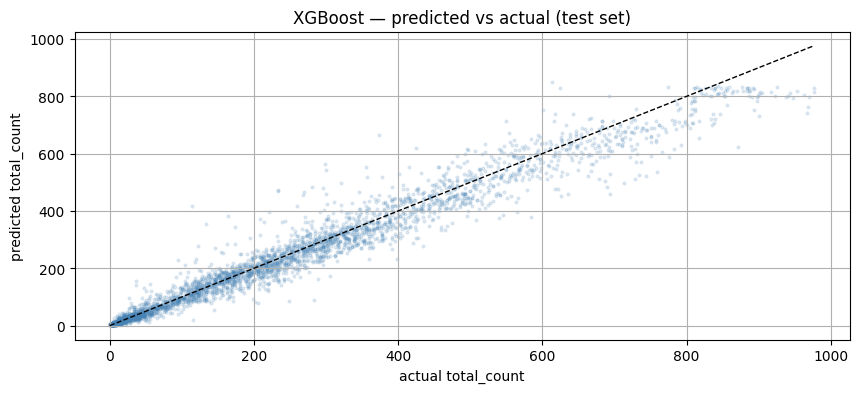

In [12]:
winner = TransformedTargetRegressor(
    regressor=Pipeline(
        [
            ("preprocess", preprocess_tree),
            ("regressor", xgb_para_configs["default"]),
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)
winner.fit(X_train, y_train)
y_pred_winner = winner.predict(X_test)

# Predicted vs actual
fig, ax = plt.subplots()
lo, hi = 0, max(y_test.max(), y_pred_winner.max())
ax.scatter(y_test, y_pred_winner, s=4, alpha=0.15, color="steelblue")
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("actual total_count")
ax.set_ylabel("predicted total_count")
ax.set_title("XGBoost — predicted vs actual (test set)")
plt.show()

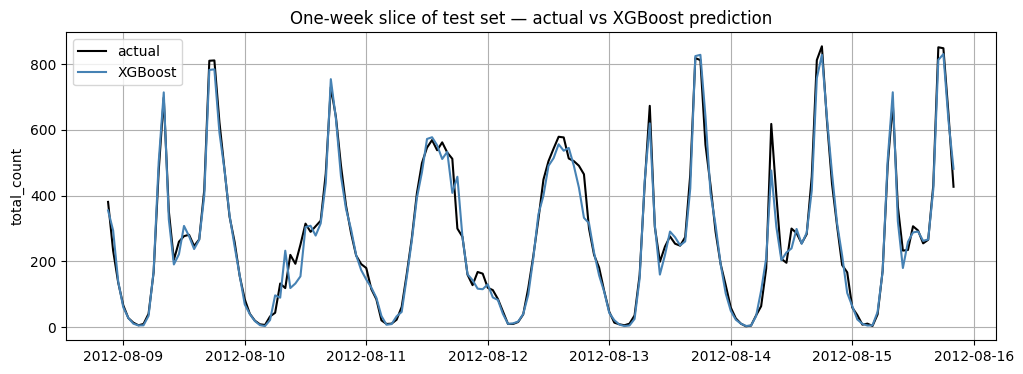

In [13]:
window = df_test.iloc[: 24 * 7].index
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    df_test.loc[window, "datetime"],
    y_test.iloc[window].values,
    label="actual",
    color="black",
)
ax.plot(
    df_test.loc[window, "datetime"],
    y_pred_winner[window],
    label="XGBoost",
    color="steelblue",
)
ax.set_title("One-week slice of test set — actual vs XGBoost prediction")
ax.set_ylabel("total_count")
ax.legend()
plt.show()

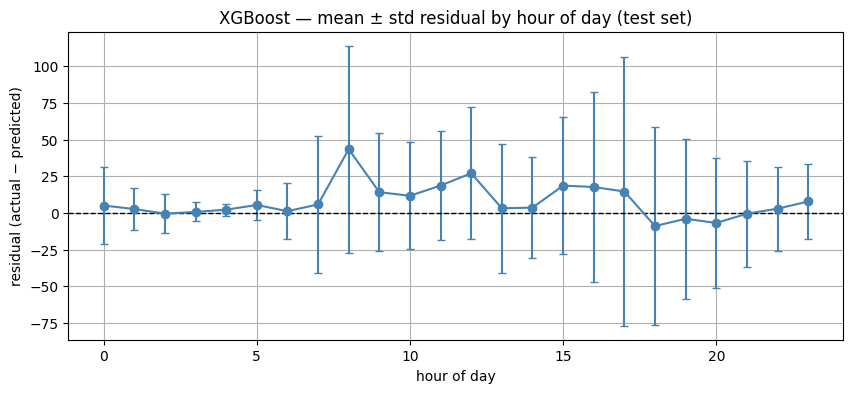

In [14]:
residuals = y_test.values - y_pred_winner
by_hour = pd.DataFrame({"hour": X_test["hour"].values, "residual": residuals})
agg = by_hour.groupby("hour")["residual"].agg(["mean", "std"])

fig, ax = plt.subplots()
ax.errorbar(
    agg.index,
    agg["mean"],
    yerr=agg["std"],
    marker="o",
    capsize=3,
    color="steelblue",
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("hour of day")
ax.set_ylabel("residual (actual − predicted)")
ax.set_title("XGBoost — mean ± std residual by hour of day (test set)")
plt.show()

**Feature importance.** A sanity check that the engineered columns (cyclic / interaction / lag) actually did real work for the winning model, rather than inflating the input matrix for free. XGBoost's gain-weighted importance shows which features the trees split on most usefully.

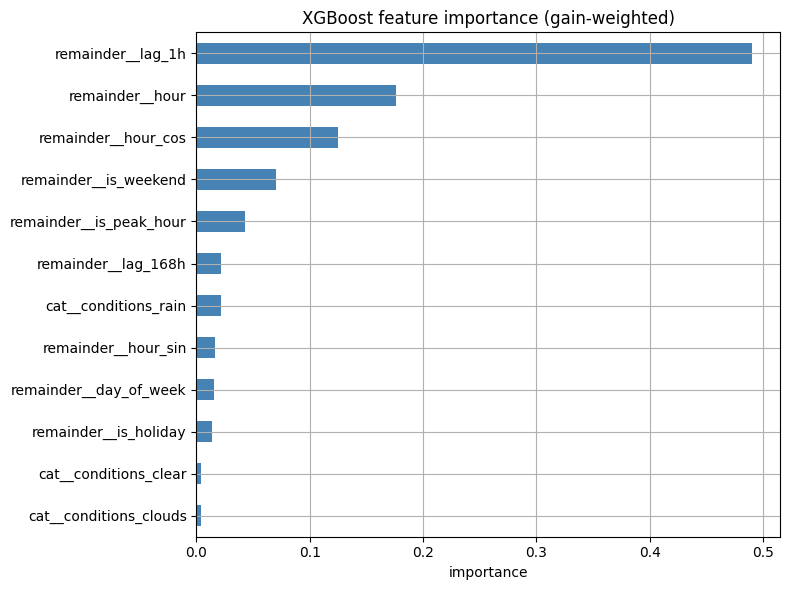

remainder__lag_1h          0.490483
remainder__hour            0.175684
remainder__hour_cos        0.124808
remainder__is_weekend      0.069905
remainder__is_peak_hour    0.042630
remainder__lag_168h        0.021601
cat__conditions_rain       0.021305
remainder__hour_sin        0.016134
remainder__day_of_week     0.015480
remainder__is_holiday      0.013928
dtype: float32

In [15]:
fitted_pipeline = winner.regressor_
fnames = fitted_pipeline.named_steps["preprocess"].get_feature_names_out()
imps = pd.Series(
    fitted_pipeline.named_steps["regressor"].feature_importances_, index=fnames
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imps.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost feature importance (gain-weighted)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()
imps.sort_values(ascending=False).head(10)

## 13. Conclusion

**Headline numbers (test set), sorted by RMSE:**

| # | Model | RMSE | MAE | R² |
|---|---|---|---|---|
| 05 | **XGBoost + log1p (default)** | **45.47** | **28.63** | **0.957** |
| 05 | XGBoost + log1p (deep) | 45.67 | 28.68 | 0.957 |
| 04 | XGBoost (default) | 46.27 | 29.19 | 0.956 |
| 04 | XGBoost (shallow) | 47.13 | 30.58 | 0.954 |
| 04 | XGBoost (deep) | 47.28 | 29.73 | 0.954 |
| 05 | XGBoost + log1p (shallow) | 48.03 | 30.17 | 0.952 |
| 03 | RandomForest | 49.79 | 30.29 | 0.949 |
| 01 | Ridge + FE | 94.54 | 62.40 | 0.815 |
| 00 | LinearRegression (baseline) | 200.34 | 135.25 | 0.174 |
| 02 | Ridge + FE + log1p | 384.37 | 160.71 | -2.057 |

**What moved the needle**

- **Model class did the most work.** Feature engineering on a linear model lifted test R² from 0.174 → 0.815 (RMSE 200 → 94) — meaningful, but capped by additivity. Moving to a tree ensemble lifted R² further to 0.949 (RF) → 0.957 (XGBoost + log1p). The bimodal hour curve and the `hour x is_weekend` interaction are non-linear by nature, and only a non-linear model can fit them without exhaustive hand-built interaction terms.
- **Lag features are the dominant signal.** `lag_1h` captures short-term trajectory and `lag_168h` (same hour last week) absorbs day-of-week structure, weekly seasonality, *and* year-over-year growth in one column. The combination is what made it sensible to drop `year`, `month`, and the weather block entirely while still beating the baseline by 4x.
- **`log1p` target helps trees, breaks linear-with-lags.** The transform gave XGBoost a small (~2% RMSE) lift on default and deep configurations. The same transform applied to Ridge exploded on test (RMSE 94 → 384) because Ridge extrapolates aggressively in log-space when 2012 lag magnitudes exceed training range, and `expm1` amplifies the extrapolation error. Trees do not extrapolate, so the loss-rebalancing benefit lands without the explosion.

**What did not help**

- **XGBoost hyperparameter tuning.** The default config (`max_depth=6, n_estimators=600, learning_rate=0.05`) is best or within rounding across both target spaces. Shallow under-fits slightly; deep over-fits without test gain. A proper cross-validated tuning pass is out of scope here, but the takeaway is that we do not need it to ship.
- **`log1p` on a linear model with lag features.** The catastrophic regression (R² -2.057) is itself the finding: target transforms interact non-trivially with the model class and the feature scale, and need to be tested together rather than assumed safe.

**Picked model.** `TransformedTargetRegressor` wrapping `XGBoost(n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, tree_method="hist")` with `log1p` / `expm1` as the target transform. Best test RMSE in the table, beats Random Forest on every metric, and required no hyperparameter search. This is the model to serialise and integrate into the Dagster pipeline in part 4.